In [42]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

%matplotlib inline

In [43]:
with open('model_bundle.pkl', 'rb') as file:
    bundle = pickle.load(file)

rf_model = bundle['model']
X_train = bundle['X_train']
y_train = bundle['y_train']
X_test = bundle['X_test']
y_test = bundle['y_test']
le = bundle['le']
feature_names = bundle['feature_names']

In [44]:
y_pred_test = rf_model.predict(X_test)
y_pred_train = rf_model.predict(X_train)

In [45]:
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
gap = train_acc - test_acc

print("ANALISIS KESEIMBANGAN MODEL (FITTING)")
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Test Accuracy  : {test_acc*100:.2f}%")
print(f"Gap (Selisih)  : {gap*100:.2f}%\n")

if train_acc < 0.70 and test_acc < 0.70:
    status = "UNDERFITTING"
    ket = "Underfitting atau terlalu sederhana dan tidak seimbang."
elif gap > 0.10:
    status = "OVERFITTING"
    ket = "Overfitting atau terlalu berlebihan dan tidak seimbang."
else:
  status = "GOOD FIT (BALANCE)"
  ket = "GoodFit(BALANCE)."

print(f"STATUS MODEL : {status}")
print(f"ANALISIS     : {ket}")

ANALISIS KESEIMBANGAN MODEL (FITTING)
Train Accuracy : 99.75%
Test Accuracy  : 94.95%
Gap (Selisih)  : 4.81%

STATUS MODEL : GOOD FIT (BALANCE)
ANALISIS     : GoodFit(BALANCE).


In [46]:
print("\nLAPORAN KLASIFIKASI DETAIL (DATA UJI)")
unique_labels_test = np.union1d(np.unique(y_test), np.unique(y_pred_test))
filtered_target_names_test = [le.classes_[label] for label in unique_labels_test]
print(classification_report(y_test, y_pred_test, labels=unique_labels_test, target_names=filtered_target_names_test))


LAPORAN KLASIFIKASI DETAIL (DATA UJI)
                    precision    recall  f1-score   support

              BAIK       0.98      0.90      0.94        63
         BERBAHAYA       0.00      0.00      0.00         1
SANGAT TIDAK SEHAT       0.97      0.95      0.96        41
            SEDANG       0.95      0.97      0.96       638
       TIDAK SEHAT       0.94      0.93      0.94       365

          accuracy                           0.95      1108
         macro avg       0.77      0.75      0.76      1108
      weighted avg       0.95      0.95      0.95      1108



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


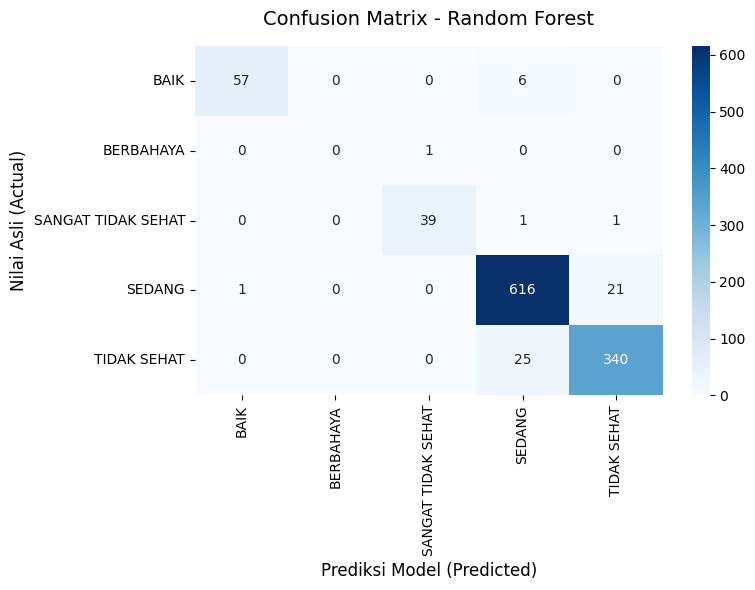

In [47]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Confusion Matrix - Random Forest', fontsize=14, pad=15)
plt.xlabel('Prediksi Model (Predicted)', fontsize=12)
plt.ylabel('Nilai Asli (Actual)', fontsize=12)
plt.tight_layout()
plt.show()


📈 Rata-rata ROC AUC Score (Macro): 0.9880



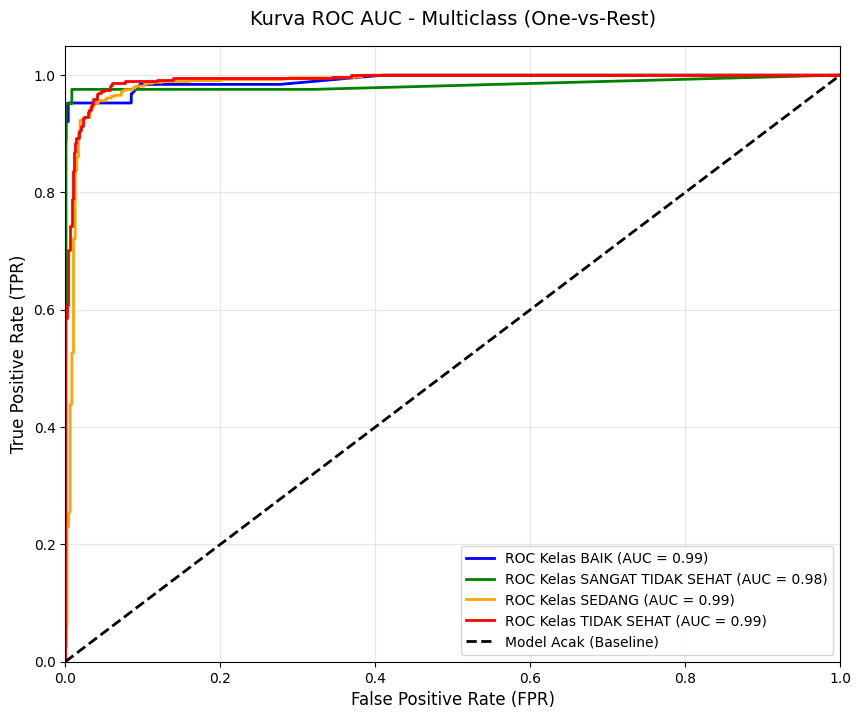

In [48]:
y_pred_proba = rf_model.predict_proba(X_test)

try:
    model_classes = rf_model.classes_

    y_test_bin = label_binarize(y_test, classes=model_classes)
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(10, 8))
    colors = ['blue', 'green', 'orange', 'red']
    valid_aucs = []

    for i in range(n_classes):
        if np.sum(y_test_bin[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
            roc_auc = auc(fpr, tpr)
            valid_aucs.append(roc_auc)

            class_idx_in_le = np.where(le.transform(le.classes_) == model_classes[i])[0][0]
            class_name = le.classes_[class_idx_in_le]

            plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                     label=f'ROC Kelas {class_name} (AUC = {roc_auc:.2f})')
        else:
            class_idx_in_le = np.where(le.transform(le.classes_) == model_classes[i])[0][0]
            class_name = le.classes_[class_idx_in_le]
            print(f"[INFO] Kelas '{class_name}' tidak ada di data uji, kurva ROC-nya dilewati.")

    if len(valid_aucs) > 0:
        roc_auc_macro = np.mean(valid_aucs)
        print(f"\n📈 Rata-rata ROC AUC Score (Macro): {roc_auc_macro:.4f}\n")
    else:
        print("\nTidak bisa menghitung ROC AUC sama sekali.")

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Model Acak (Baseline)')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('Kurva ROC AUC - Multiclass (One-vs-Rest)', fontsize=14, pad=15)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.show()

except Exception as e:
    print(f"\n[PERHATIAN] Gagal menggambar kurva ROC AUC.")
    print(f"Detail Error: {e}")

/tmp/ipykernel_4783/2844227987.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pentingnya', y='Fitur', data=fi_df, palette='viridis')


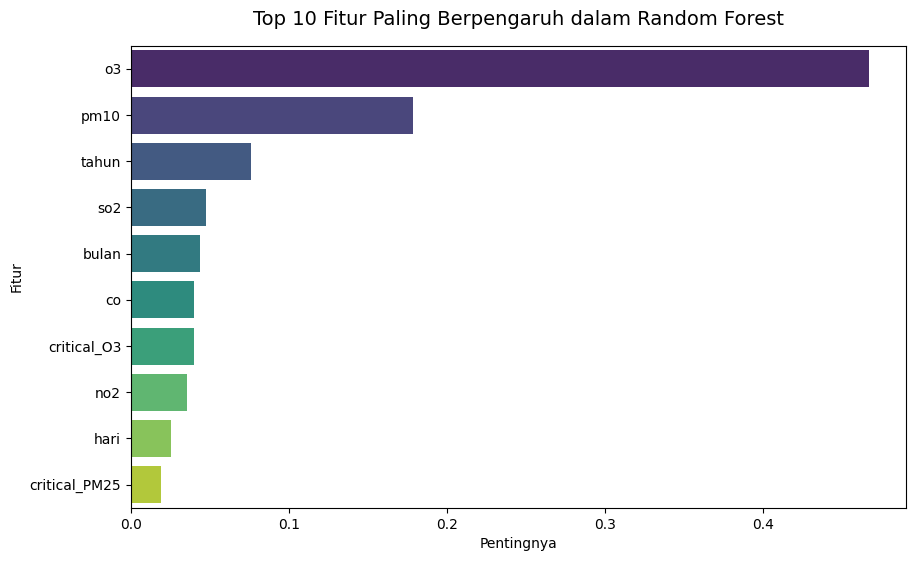

In [49]:
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'Fitur': feature_names, 'Pentingnya': importances})
fi_df = fi_df.sort_values(by='Pentingnya', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Pentingnya', y='Fitur', data=fi_df, palette='viridis')
plt.title('Top 10 Fitur Paling Berpengaruh dalam Random Forest', fontsize=14, pad=15)
plt.show()